In [11]:
# Step No 1 : Import  required libraries 
import numpy as np             # Numerical operations 
import pandas as pd            # data manupulation 
import matplotlib.pyplot as plt# Plotting 
import seaborn as sns          # Advanced Visualization 

from sklearn.model_selection import train_test_split # data Splitting 
from sklearn.ensemble import RandomForestClassifier # Random Forest Model

# Step No : 2 Data Loading and Exploration 
# Load the Dataset 
df = pd.read_csv("Social_Network_Ads.csv")
df.to_string

# Step No : 3 Understanding the data 
# Display the first few rows of the dataset 
print(df.head())

# Statistical summary of the dataset 
print(df.describe())

# Check column names and data types 
print(df.info())

# Step No : 4 Data Cleaning and Preprocessing 
# Check for missing values 
print(df.isnull().sum())

# Check for duplicate values 
print(df.duplicated().sum())

# Drop duplicate rows if found 
df = df.drop_duplicates()

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Nul

In [12]:
# if dataset has user ID column remove because it does not help prediction 
if "User ID " in df.columns:
    df = df.drop("User ID" , axis=1)
# If dataset has gender column , convert it into numeric from
if "Gender" in df.columns:
    df["Gender"] = df["Gender"].map({"Male": 1 , "Female": 0})
    



In [13]:
# Step 5 : Features and Target Splitting 
# Using Age and EstimateSalary as input features
X = df[["Age" , "EstimatedSalary"]]
y = df[["Purchased"]]

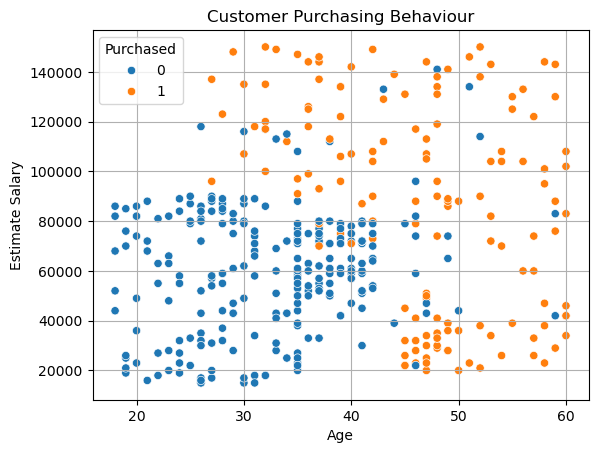

In [14]:
# Step 6 : Visualization
# Scatter Plot of Age Vs EstimateSalary colored by Purchased
sns.scatterplot(x="Age" , y = "EstimatedSalary" , hue="Purchased" , data = df)
plt.title("Customer Purchasing Behaviour")
plt.xlabel("Age")
plt.ylabel("Estimate Salary")
plt.grid()
plt.savefig("images/random_forest_visualization.png")
plt.show()



In [15]:
# Step 7 : Train Test Split for Model Evaluation
X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.2 , random_state=42)

In [16]:
# Step 8 : Feature Scaling 
# Random Forest does not require scaling , but included for consistency in pipline 
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

# Scale training data (fit + transform)
X_train = sc.fit_transform(X_train)

# Scale test data (only transfrom no fitting )
X_test = sc.transform(X_test)



In [17]:
# Step 9 : Intialize Model 
# Create Random Rorest Model with 100 decision trees 
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [18]:
# Step 10 : Model Training 
# Train the model using trianing data 
model.fit(X_train , y_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=42)

In [19]:
# Step 11 : Prediction 
# Predict outcomes for test data 
y_pred = model.predict(X_test)

In [20]:
# Step 12 : Model Evaluation
from sklearn.metrics import confusion_matrix, accuracy_score

# Display confusion matrix to evalute classification performance 
print("Confusion Matrix : ")
print(confusion_matrix(y_test , y_pred))

# Display Accuracy score 
print("Accuracy Score : ")
print(accuracy_score(y_test , y_pred))


Confusion Matrix : 
[[46  6]
 [ 3 25]]
Accuracy Score : 
0.8875


In [21]:
# Step 13 User Input 
# Take user input for prediction
age = int(input("Enter the Age : "))
salary = int(input("Enter the Estimated Salary : "))

#convert input into numpy array
user_data = np.array([[age , salary]])

# Apply same scaling as training data 
user_data = sc.transform(user_data)
 

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [22]:
# Step 14 : Predication on User Input 
# Predict whether user will purchase or not 
result = model.predict(user_data)

In [23]:
# Step 15 : final Output 
# Display result in user - friendly format 
if result[0] == 1:
    print("Customer will purchase (Target Customer )")
else:
    print("Customer will not purchase (No Target)")

Customer will not purchase (No Target)
